<a href="https://colab.research.google.com/github/DRychter2006/Programowanie2/blob/main/Lung_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Programowanie2/dataset_clean.csv")

#Podstawowa analiza statystyczna

Statystyki opisowe

In [ ]:
df.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,0.475728,62.673139,0.563107,0.569579,0.498382,0.501618,0.504854,0.673139,0.556634,0.556634,0.556634,0.579288,0.640777,0.469256,0.556634,0.873786
std,0.500221,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,0.332629
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,62.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,87.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


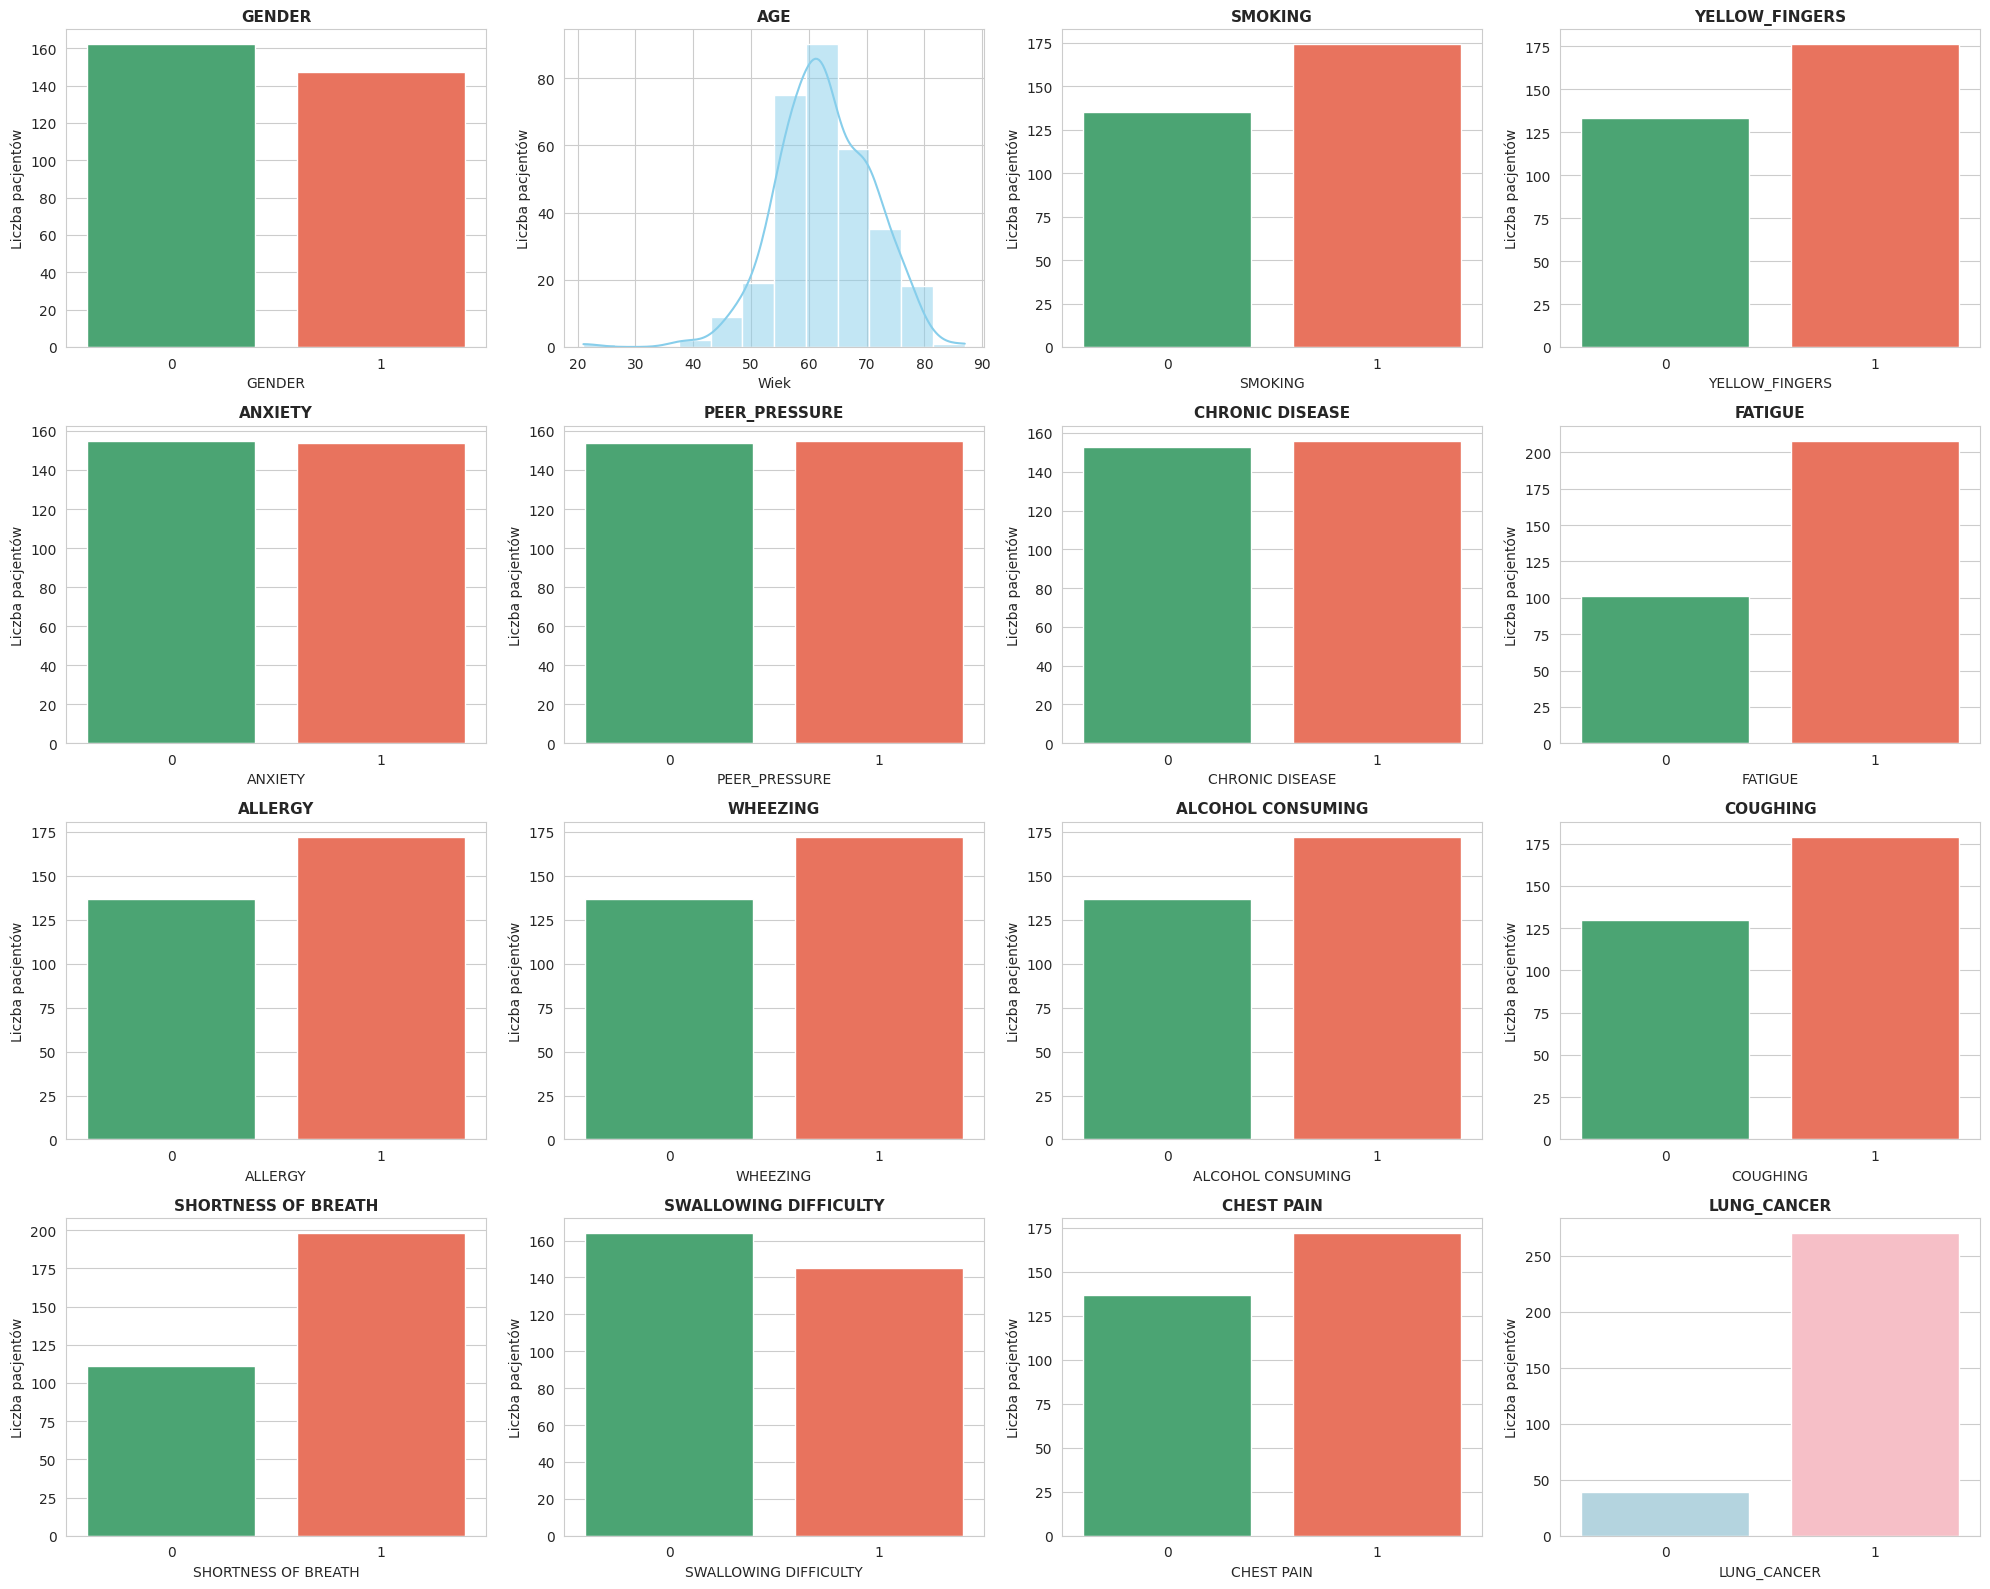

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wczytanie danych
df = pd.read_csv("/content/drive/MyDrive/Programowanie2/dataset_clean.csv")

sns.set_style("whitegrid")

# Lista kolumn
columns = df.columns

# Liczba wykresów
n_cols = 4
n_rows = (len(columns) + n_cols - 1) // n_cols

# Tworzenie siatki wykresów
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(columns):

    # Histogram dla wieku
    if col == 'AGE':
        sns.histplot(
            df[col],
            bins=12,
            kde=True,
            color='skyblue',
            ax=axes[i]
        )
        axes[i].set_xlabel("Wiek")
        axes[i].set_ylabel("Liczba pacjentów")

    # Specjalne kolory dla zmiennej docelowej
    elif col == 'LUNG_CANCER':
        sns.countplot(
            x=col,
            data=df,
            hue=col,
            palette={0: 'lightblue', 1: 'lightpink'},
            legend=False,
            ax=axes[i]
        )
        axes[i].set_ylabel("Liczba pacjentów")

    # Wszystkie pozostałe zmienne binarne
    else:
        sns.countplot(
            x=col,
            data=df,
            hue=col,
            palette={0: 'mediumseagreen', 1: 'tomato'},
            legend=False,
            ax=axes[i]
        )
        axes[i].set_ylabel("Liczba pacjentów")

    axes[i].set_title(col, fontsize=11, fontweight='bold')

# Usunięcie pustych osi
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#Macierz korelacji

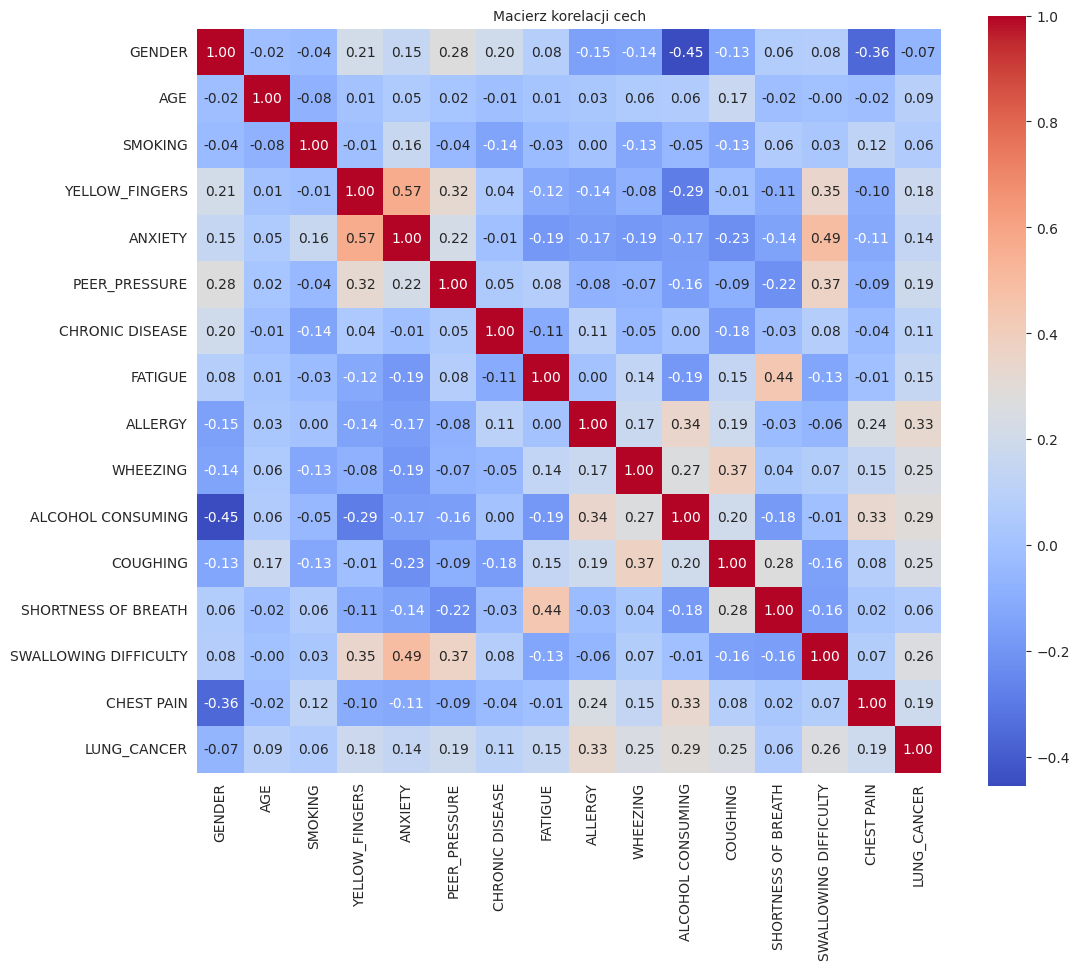

In [ ]:
# Macierz korelacji
corr_matrix = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Macierz korelacji cech", fontsize=10)
plt.show()

#Cechy najsilniej skorelowane z LUNG_CANCER

/tmp/ipykernel_5018/2872230363.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


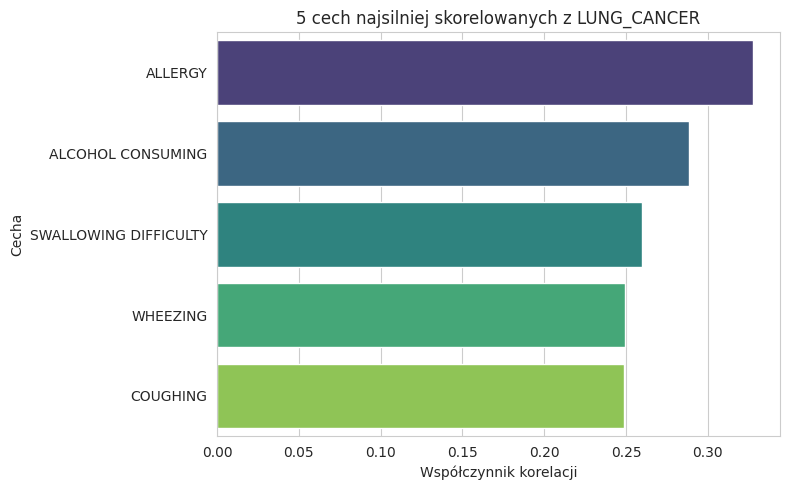

5 cech najbardziej związanych z LUNG_CANCER:
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
Name: LUNG_CANCER, dtype: float64


In [ ]:
# Korelacje z LUNG_CANCER
corr_target = (
    df.corr()['LUNG_CANCER']
    .drop('LUNG_CANCER')
    .sort_values(key=abs, ascending=False)
)

top5 = corr_target.head(5)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top5.values,
    y=top5.index,
    palette='viridis'
)

plt.title('5 cech najsilniej skorelowanych z LUNG_CANCER')
plt.xlabel('Współczynnik korelacji')
plt.ylabel('Cecha')

plt.tight_layout()
plt.show()

#Wypisane wartości skorelowanych z LUNG_CANCER
corr_target = (
    df.corr()['LUNG_CANCER']
    .drop('LUNG_CANCER')
    .sort_values(key=abs, ascending=False)
)

print("5 cech najbardziej związanych z LUNG_CANCER:")
print(corr_target.head(5))

#Train-Test split
Funkcja stratify

In [ ]:
from sklearn.model_selection import train_test_split

# Cechy (X)
X = df.drop('LUNG_CANCER', axis=1)

# Zmienna docelowa (Y)
y = df['LUNG_CANCER']

# Podział na treningowy i testowy 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

#sprawdzam, czy podział danych został zachowany
print("Cały zbiór:")
print(y.value_counts(normalize=True) * 100)

print("\nZbiór treningowy:")
print(y_train.value_counts(normalize=True) * 100)

print("\nZbiór testowy:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (247, 15)
X_test: (62, 15)
y_train: (247,)
y_test: (62,)
Cały zbiór:
LUNG_CANCER
1    87.378641
0    12.621359
Name: proportion, dtype: float64

Zbiór treningowy:
LUNG_CANCER
1    87.449393
0    12.550607
Name: proportion, dtype: float64

Zbiór testowy:
LUNG_CANCER
1    87.096774
0    12.903226
Name: proportion, dtype: float64


#Pipeline
Logistic Regression, Random Forest Classifier, XGBoost Classifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',  #uwiarygadniam dane
        random_state=42,
        max_iter=1000
    ))
])

# Random Forest
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42
    ))
])

# XGBoost
pipe_xgb = Pipeline([
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

#Trenowanie

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

results = {}

for name, model in models.items():

    # Trenowanie
    model.fit(X_train, y_train)

    # Predykcje
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metryki
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# Wyświetlenie wyników
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")


Logistic Regression
Accuracy: 0.8710
Precision: 1.0000
Recall: 0.8519
F1-score: 0.9200
ROC-AUC: 0.9537

Random Forest
Accuracy: 0.9032
Precision: 0.9444
Recall: 0.9444
F1-score: 0.9444
ROC-AUC: 0.9491

XGBoost
Accuracy: 0.8871
Precision: 0.9273
Recall: 0.9444
F1-score: 0.9358
ROC-AUC: 0.9306


#Raport Klasyfikacji

In [ ]:
from sklearn.metrics import classification_report

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         8
           1       1.00      0.85      0.92        54

    accuracy                           0.87        62
   macro avg       0.75      0.93      0.79        62
weighted avg       0.94      0.87      0.89        62


Random Forest
              precision    recall  f1-score   support

           0       0.62      0.62      0.62         8
           1       0.94      0.94      0.94        54

    accuracy                           0.90        62
   macro avg       0.78      0.78      0.78        62
weighted avg       0.90      0.90      0.90        62


XGBoost
              precision    recall  f1-score   support

           0       0.57      0.50      0.53         8
           1       0.93      0.94      0.94        54

    accuracy                           0.89        62
   macro avg       0.75      0.72      0.73        62
weighted avg       0.88      

#Wizualizacja macierzy i pomyłek

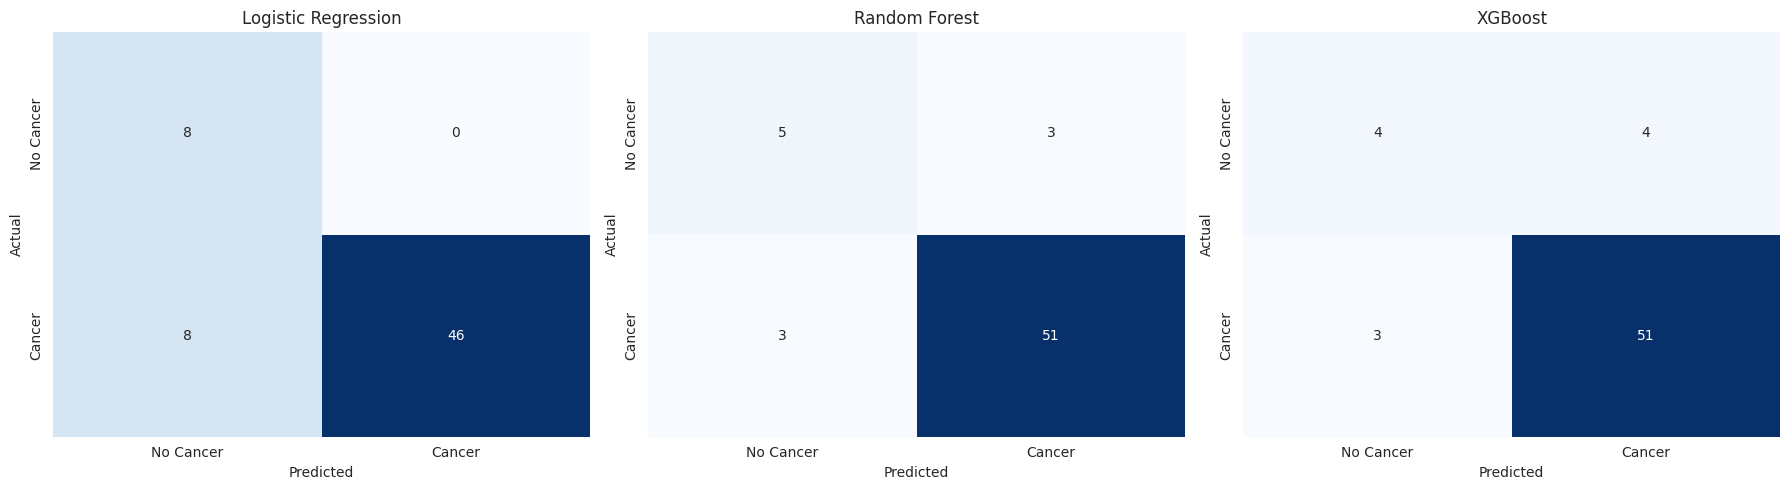

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Cancer", "Cancer"],
        yticklabels=["No Cancer", "Cancer"],
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

#Krzywa ROC

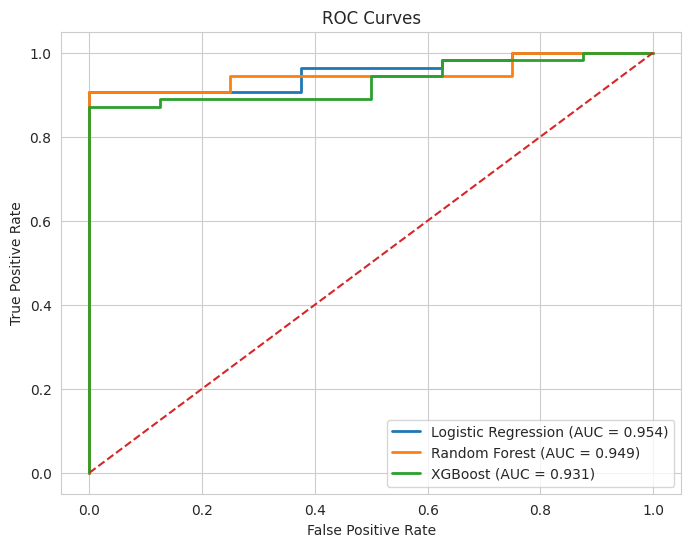

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()

#Porównanie modeli

In [ ]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8710     1.0000  0.8519    0.9200   0.9537
1        Random Forest    0.9032     0.9444  0.9444    0.9444   0.9491
2              XGBoost    0.8871     0.9273  0.9444    0.9358   0.9306


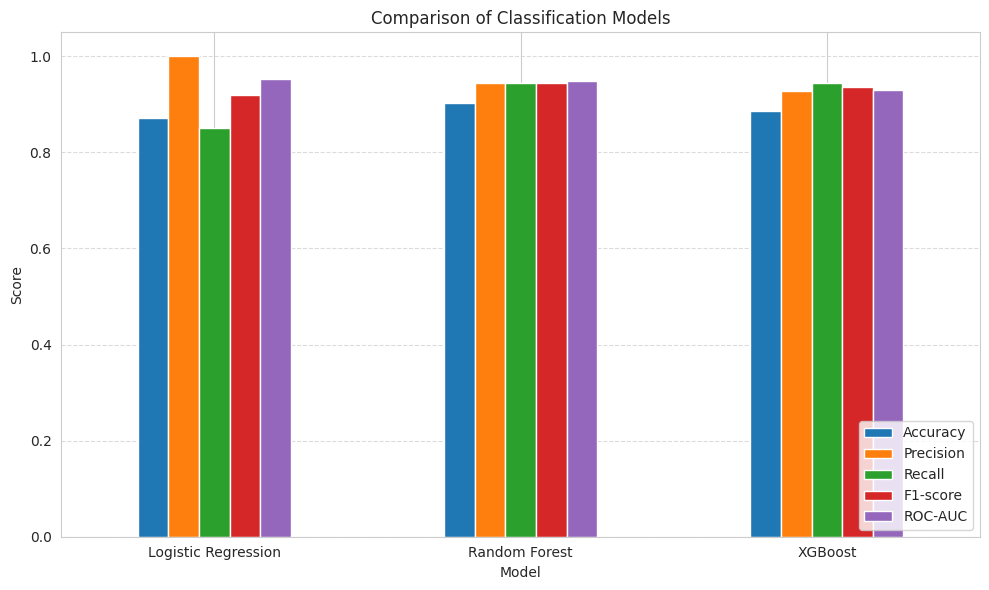

In [ ]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")

plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

#Wniosek końcowy

In [ ]:
best_model = results_df.iloc[0]

print("Best model:")
print(f"Model: {best_model['Model']}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")

Best model:
Model: Logistic Regression
ROC-AUC: 0.9537
